# Clustering
## This code aims to group songs into distinct mood categories using a unsupervised clustering model based on audio features like valence, energy, dancaeability, acousticness, and tempo.
Valence → emotional positivity

    High = happy, cheerful

    Low = sad, gloomy

Energy → intensity and loudness

    High = energetic, powerful

    Low = calm, mellow

Danceability → how rhythmically suitable a track is for dancing

    High = groovy, poppy

    Low = stiff, slow, abstract

Acousticness → how acoustic (vs. electronic) a track is

    High = more natural, mellow, often singer-songwriter or ambient

    Low = electronic, produced

Tempo → speed in beats per minute

    High = fast-paced

    Low = slow-paced



Features Excluded:

These aren’t related to how a song feels emotionally:

track_id, track_name, artists, album_name	Metadata - not mood-relevant

popularity - Reflects marketing, not emotional tone

explicit - Censorship flag, not a mood indicator

key, mode, time_signature - Theoretically related to mood in music theory but not strongly predictive in ML unless you're doing advanced modeling

track_genre - Too broad or categorical; use only if doing supervised mood prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # Optional: for visualizing clusters
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA  # Optional

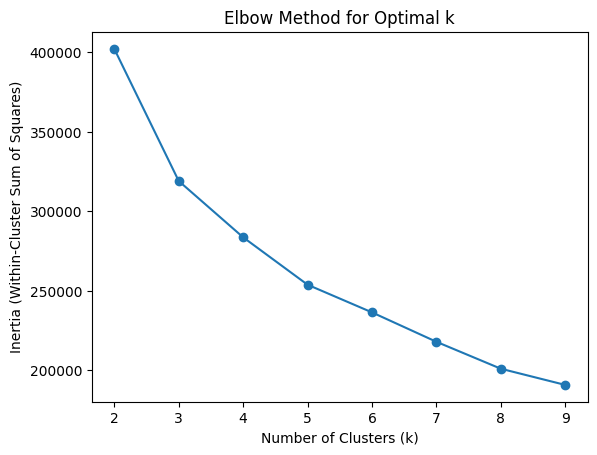

In [2]:
# Load dataset
df = pd.read_csv("spotify_dataset.csv")  # Use your actual CSV

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df[['valence', 'energy', 'danceability', 'acousticness', 'tempo']])


inertia = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [3]:
optimal_k = 4  # change this to the value from your elbow
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
df['cluster'] = kmeans.fit_predict(x_scaled)

In [4]:
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),  # convert back to original scale
    columns=df[['valence', 'energy', 'danceability', 'acousticness', 'tempo']].columns
)
print(centers)

    valence    energy  danceability  acousticness       tempo
0  0.455700  0.801775      0.462359      0.124934  162.540803
1  0.293845  0.750938      0.545327      0.096755  110.723308
2  0.316143  0.303751      0.467885      0.784430  109.577168
3  0.723837  0.707322      0.707193      0.253116  117.204983


 Interpretation of average trait values for each cluster
 
    Valence → emotional positivity

        High = happy, cheerful

        Low = sad, gloomy

    Energy → intensity and loudness

        High = energetic, powerful

        Low = calm, mellow

    Danceability → how rhythmically suitable a track is for dancing

        High = groovy, poppy

        Low = stiff, slow, abstract

    Acousticness → how acoustic (vs. electronic) a track is

        High = more natural, mellow, often singer-songwriter or ambient

        Low = electronic, produced

    Tempo → speed in beats per minute

        High = fast-paced

        Low = slow-paced

In [5]:
cluster_to_mood = {
    0: "Energetic",
    1: "Dark/Intense",
    2: "Sad/Calm",
    3: "Happy/Upbeat"
}

df['mood'] = df['cluster'].map(cluster_to_mood)

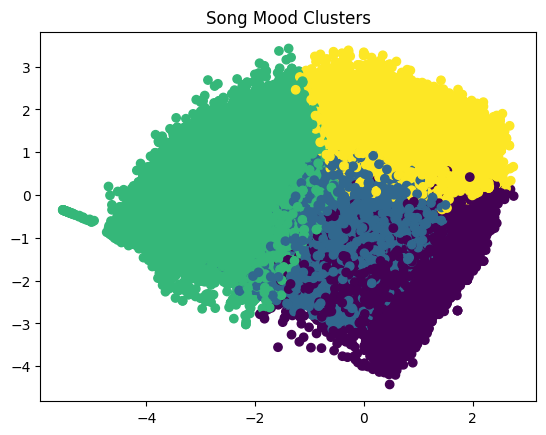

In [6]:
pca = PCA(n_components=2)
X_2D = pca.fit_transform(x_scaled)

plt.scatter(X_2D[:, 0], X_2D[:, 1], c=df['cluster'], cmap='viridis')
plt.title("Song Mood Clusters")
plt.show()